In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Yashidocuments', 'IMG20220303132341-1.jpg', 'IMG_20221108_172156~2.jpg', 'contacts.vcf', 'carryover fees.pdf', '2022071081_aadharcard.pdf', '2022071081_IDCard.jpg', 'IMG-20240111-WA0002.jpg', 'Screenshot_2024-01-11-22-51-32-741_cn.wps.xiaomi.abroad.lite.jpg', 'Nainital', 'Colab Notebooks', 'IMG-20260125-WA0103.jpg', 'Sarojini Hostel - MMMUT, Resident Information Form.gform', 'Sarojini Hostel-MMMUT, Resident Information Form (File responses)', 'Sarojini Hostel-MMMUT, Resident Information Form.gform', 'Sarojini Hostel-MMMUT, Resident Information Form (Responses).gsheet']


In [8]:
import pandas as pd

file_path = "/content/drive/MyDrive/Colab Notebooks/ML_Projects/Company_Bankruptcy_Prediction/company_bankruptcy.csv"

df = pd.read_csv(file_path)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/ML_Projects/Company_Bankruptcy_Prediction/company_bankruptcy.csv


In [9]:
df.head()

,net_profit_total_assets,total_liabilities_total_assets,working_capital_total_assets,current_assets_short_term_liabilities,retained_earnings_total_assets,ebit_total_assets,book_value_equity_total_liabilities,sales_total_assets,equity_total_assets,gross_profit_short_term_liabilities,...,sales_n_1,profit_on_sales,ebit_sales,rotation_receivables_inventories,revenue,total_costs,profit_on_operating_activities_financial_expenses,total_assets,profit_loss_on_financial_activities_total_assets,class
0,0.042017,0.286985,0.365793,3.405547,0.320683,0.177485,3.666020,2.173419,0.643552,2.833671,...,4.252274e+06,0.160073,0.141446,24.884043,1.972697e+07,1.365002e+07,3.222562,5.417706e+06,-0.014579,0
1,0.115158,0.431660,0.300040,1.575647,0.216205,0.261340,1.027964,2.195910,0.374286,2.439779,...,9.239885e+06,0.146813,0.269198,17.864539,2.266291e+07,7.411363e+06,3.386384,2.974746e+06,0.008023,0
2,0.103599,0.267988,0.368644,2.334255,0.450230,0.227660,3.624409,1.913029,0.715567,0.800840,...,1.246470e+07,0.222446,0.323127,3.850949,3.762045e+06,6.875725e+05,5.685759,1.365534e+07,0.031870,0
3,0.088314,0.459332,0.104545,1.555424,0.321099,0.285080,1.777924,1.961170,0.702696,1.146264,...,1.815481e+07,0.104991,0.090101,11.750822,3.283246e+06,9.093382e+06,6.303083,2.733266e+06,0.096704,0
4,0.170130,0.475806,0.131289,3.155182,0.089554,0.061574,2.154708,2.329317,0.720121,2.772301,...,7.946010e+05,0.144576,0.238292,25.214705,1.507119e+07,1.210692e+07,9.972226,1.046824e+06,0.002282,0


In [10]:
df.shape

(10000, 31)

In [11]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

In [12]:
df.columns

Index(['net_profit_total_assets', 'total_liabilities_total_assets',
       'working_capital_total_assets', 'current_assets_short_term_liabilities',
       'retained_earnings_total_assets', 'ebit_total_assets',
       'book_value_equity_total_liabilities', 'sales_total_assets',
       'equity_total_assets', 'gross_profit_short_term_liabilities',
       'gross_profit_total_assets',
       'operating_expenses_short_term_liabilities',
       'operating_expenses_total_liabilities',
       'profit_on_operating_activities_total_assets', 'net_profit_sales',
       'gross_profit_sales', 'current_assets_total_liabilities',
       'short_term_liabilities_total_assets', 'equity_fixed_assets',
       'constant_capital_fixed_assets', 'working_capital', 'sales_n_1',
       'profit_on_sales', 'ebit_sales', 'rotation_receivables_inventories',
       'revenue', 'total_costs',
       'profit_on_operating_activities_financial_expenses', 'total_assets',
       'profit_loss_on_financial_activities_total_ass

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   net_profit_total_assets                            10000 non-null  float64
 1   total_liabilities_total_assets                     10000 non-null  float64
 2   working_capital_total_assets                       10000 non-null  float64
 3   current_assets_short_term_liabilities              10000 non-null  float64
 4   retained_earnings_total_assets                     10000 non-null  float64
 5   ebit_total_assets                                  10000 non-null  float64
 6   book_value_equity_total_liabilities                10000 non-null  float64
 7   sales_total_assets                                 10000 non-null  float64
 8   equity_total_assets                                10000 non-null  float64
 9   gross_p

In [14]:
df.describe()

,net_profit_total_assets,total_liabilities_total_assets,working_capital_total_assets,current_assets_short_term_liabilities,retained_earnings_total_assets,ebit_total_assets,book_value_equity_total_liabilities,sales_total_assets,equity_total_assets,gross_profit_short_term_liabilities,gross_profit_total_assets,operating_expenses_short_term_liabilities,operating_expenses_total_liabilities,profit_on_operating_activities_total_assets,net_profit_sales,gross_profit_sales,current_assets_total_liabilities,short_term_liabilities_total_assets,equity_fixed_assets,constant_capital_fixed_assets,working_capital,sales_n_1,profit_on_sales,ebit_sales,rotation_receivables_inventories,revenue,total_costs,profit_on_operating_activities_financial_expenses,total_assets,profit_loss_on_financial_activities_total_assets,class
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,0.117513,0.456917,0.208698,2.267858,0.253136,0.151343,2.404626,1.609061,0.547464,1.658191,0.232973,0.918529,0.508137,0.158928,0.097693,0.308813,2.023889,0.268920,3.140006,3.758829,9.975365e+05,9.828817e+06,0.137434,0.201324,16.255829,1.253476e+07,9.950010e+06,5.422511,1.504832e+07,0.020476,0.050000
std,0.106892,0.198057,0.124749,0.742963,0.159554,0.101852,0.956447,0.521326,0.174547,0.798947,0.118122,0.357904,0.178009,0.098217,0.097309,0.125986,0.605639,0.126836,1.119937,1.337318,6.044830e+05,5.776762e+06,0.085562,0.102770,7.751105,7.114823e+06,5.582256e+06,2.760416,8.408323e+06,0.048166,0.217956
min,-0.498072,0.200008,-0.299433,0.300110,-0.399286,-0.298771,0.100419,0.300048,-0.199138,-0.491549,-0.297864,0.300081,0.200091,-0.297984,-0.499256,-0.199921,0.300246,0.100002,0.201178,0.301668,-4.981875e+05,1.120275e+05,-0.299996,-0.248561,2.002424,2.018949e+05,2.553905e+05,-1.997171,5.136795e+05,-0.149019,0.000000
25%,0.068896,0.317652,0.124972,1.689707,0.142989,0.086992,1.645137,1.164756,0.441393,1.035596,0.164102,0.611624,0.356499,0.102064,0.064872,0.225184,1.584798,0.177781,2.241141,2.687351,5.089583e+05,4.570230e+06,0.093814,0.138694,9.576211,6.218417e+06,5.109511e+06,3.289370,7.753578e+06,-0.016666,0.000000
50%,0.129124,0.435134,0.215191,2.299300,0.262411,0.160019,2.429008,1.612029,0.561365,1.673055,0.243856,0.918275,0.505224,0.167215,0.111502,0.316683,2.042013,0.256598,3.165139,3.802865,1.018352e+06,9.711135e+06,0.146815,0.210578,16.208144,1.240428e+07,9.708162e+06,5.504658,1.468168e+07,0.021210,0.000000
75%,0.190631,0.552744,0.307614,2.885712,0.381118,0.230400,3.221350,2.059097,0.680768,2.336582,0.322142,1.216894,0.659207,0.231935,0.156034,0.408161,2.527259,0.334619,4.097330,4.872896,1.513076e+06,1.489199e+07,0.198321,0.280711,22.712835,1.880190e+07,1.475944e+07,7.731437,2.243501e+07,0.060687,0.000000
max,0.249979,1.498894,0.399992,3.499633,0.499956,0.299966,3.999528,2.499459,0.799860,2.999980,0.399945,1.996508,0.999225,0.299975,0.199975,0.499941,2.999713,0.899375,4.999737,5.999929,1.999693e+06,1.999604e+07,0.249983,0.349977,29.999440,2.499559e+07,1.999946e+07,9.999052,2.999741e+07,0.099982,1.000000


In [15]:
missing_values = df.isnull().sum()

print(missing_values)

net_profit_total_assets                              0
total_liabilities_total_assets                       0
working_capital_total_assets                         0
current_assets_short_term_liabilities                0
retained_earnings_total_assets                       0
ebit_total_assets                                    0
book_value_equity_total_liabilities                  0
sales_total_assets                                   0
equity_total_assets                                  0
gross_profit_short_term_liabilities                  0
gross_profit_total_assets                            0
operating_expenses_short_term_liabilities            0
operating_expenses_total_liabilities                 0
profit_on_operating_activities_total_assets          0
net_profit_sales                                     0
gross_profit_sales                                   0
current_assets_total_liabilities                     0
short_term_liabilities_total_assets                  0
equity_fix

In [16]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [17]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [18]:
df["class"].value_counts()

,count
class,
0,9500
1,500


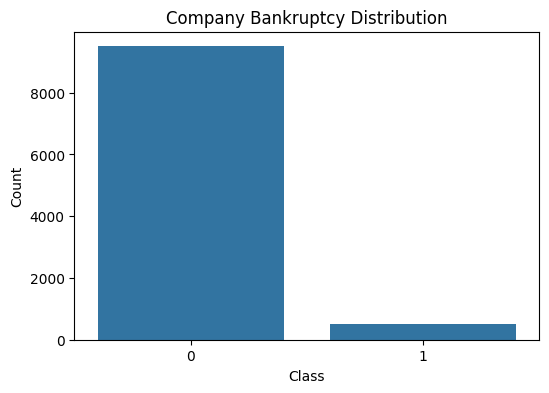

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="class",
    data=df
)

plt.title("Company Bankruptcy Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [20]:
correlation = df.corr()["class"].sort_values(ascending=False)

print(correlation)

class                                                1.000000
total_liabilities_total_assets                       0.723821
short_term_liabilities_total_assets                  0.701552
operating_expenses_short_term_liabilities            0.195211
operating_expenses_total_liabilities                 0.187158
rotation_receivables_inventories                    -0.149782
total_assets                                        -0.191064
total_costs                                         -0.222784
revenue                                             -0.274141
sales_n_1                                           -0.287453
sales_total_assets                                  -0.382031
profit_loss_on_financial_activities_total_assets    -0.430325
working_capital                                     -0.461423
equity_fixed_assets                                 -0.466240
constant_capital_fixed_assets                       -0.468135
book_value_equity_total_liabilities                 -0.472995
gross_pr

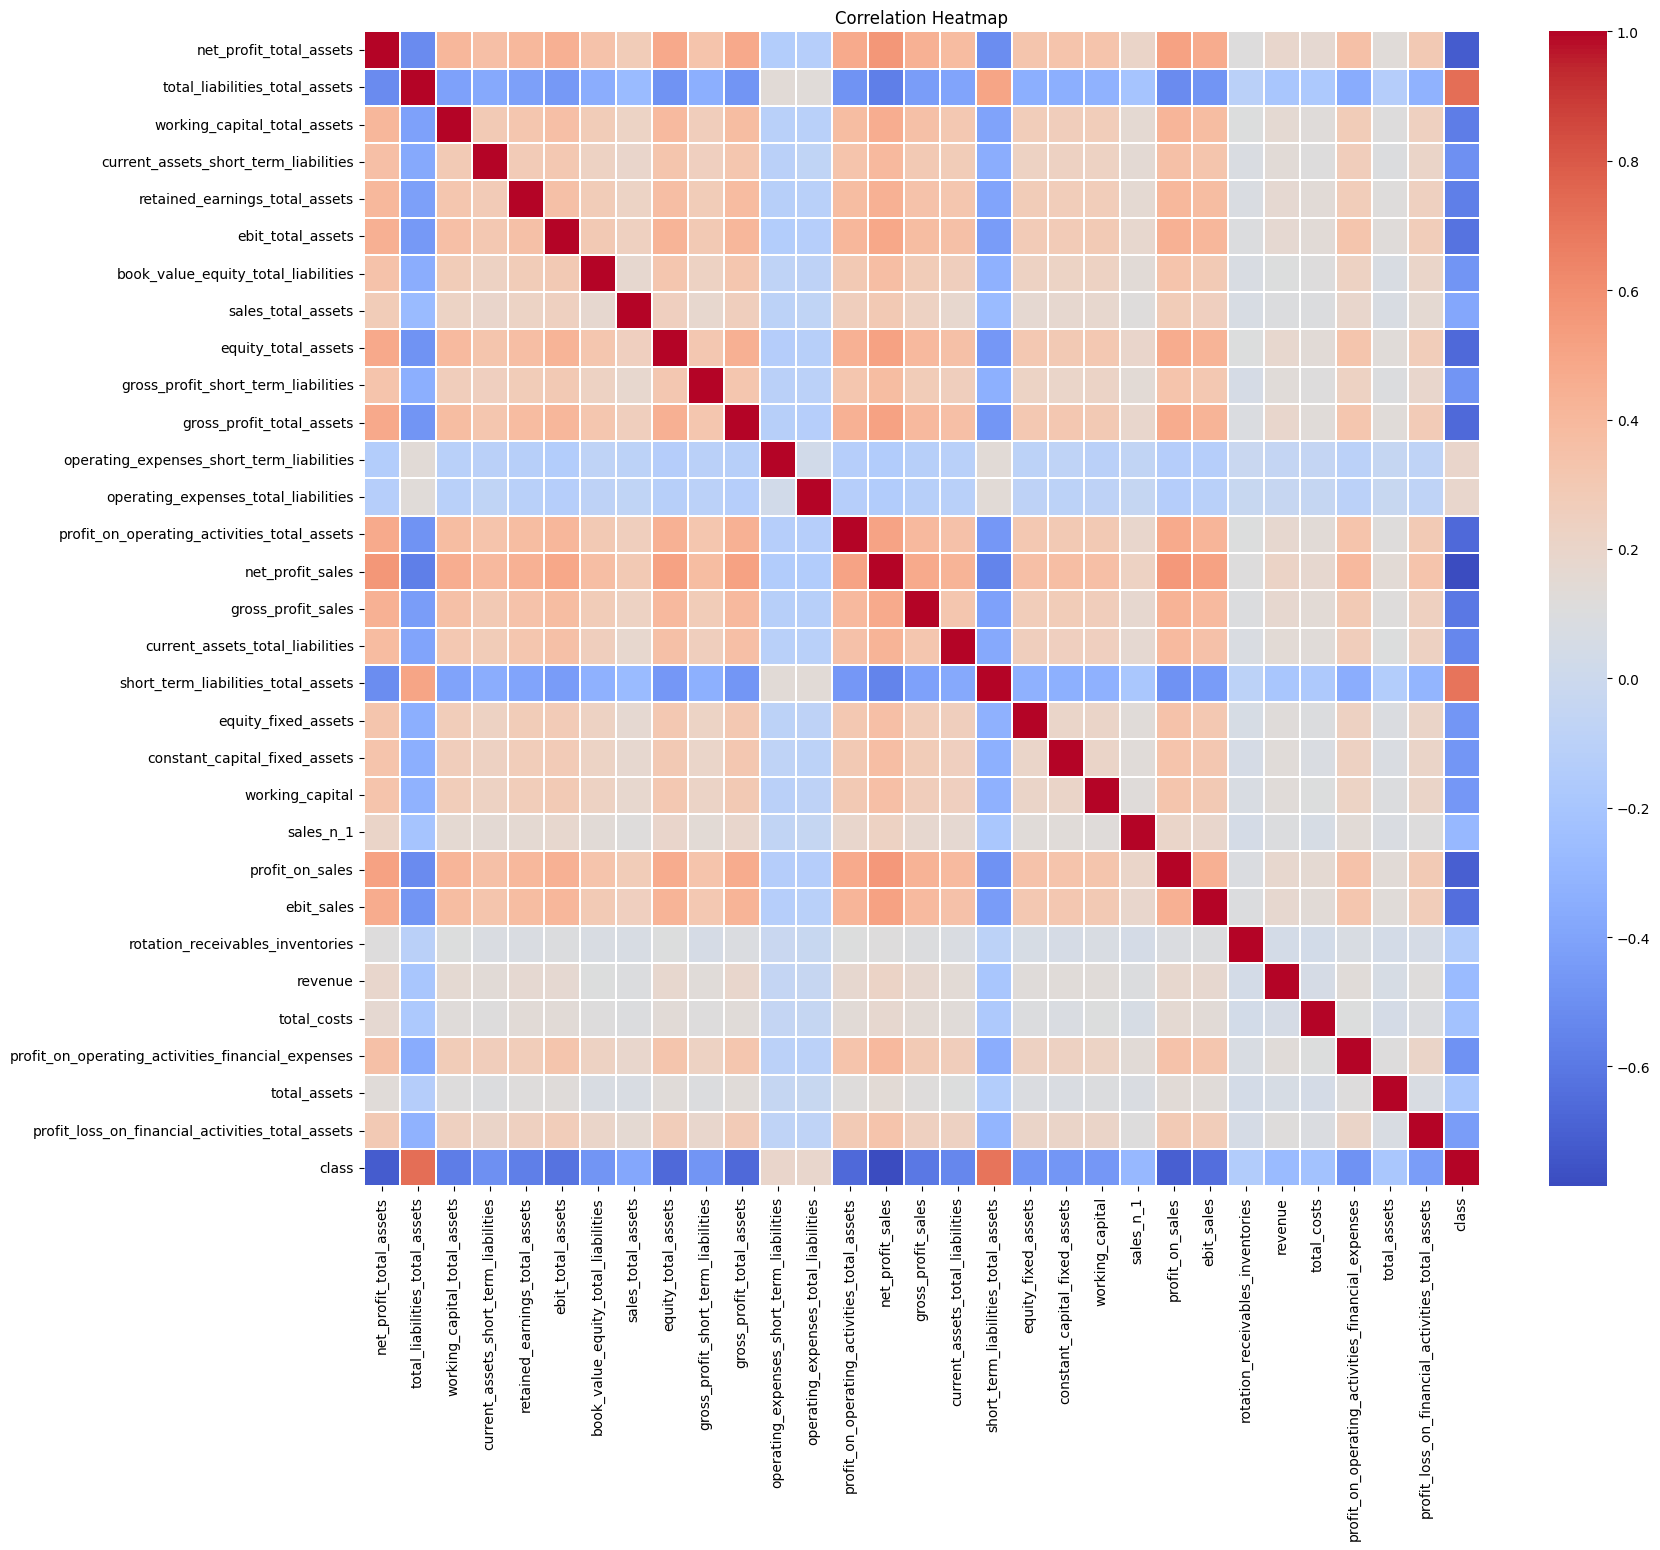

In [21]:
plt.figure(figsize=(18,15))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [23]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [24]:
correlation = df.corr()["class"].sort_values(ascending=False)
print(correlation)

class                                                1.000000
total_liabilities_total_assets                       0.723821
short_term_liabilities_total_assets                  0.701552
operating_expenses_short_term_liabilities            0.195211
operating_expenses_total_liabilities                 0.187158
rotation_receivables_inventories                    -0.149782
total_assets                                        -0.191064
total_costs                                         -0.222784
revenue                                             -0.274141
sales_n_1                                           -0.287453
sales_total_assets                                  -0.382031
profit_loss_on_financial_activities_total_assets    -0.430325
working_capital                                     -0.461423
equity_fixed_assets                                 -0.466240
constant_capital_fixed_assets                       -0.468135
book_value_equity_total_liabilities                 -0.472995
gross_pr

In [25]:
# Count companies in each class
print(df["class"].value_counts())

class
0    9500
1     500
Name: count, dtype: int64


In [26]:
# Features
X = df.drop("class", axis=1)

# Target
y = df["class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 30)
Target Shape: (10000,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (8000, 30)
Testing Set: (2000, 30)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [29]:
print("Training Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Class Distribution:
class
0    7600
1     400
Name: count, dtype: int64

Testing Class Distribution:
class
0    1900
1     100
Name: count, dtype: int64


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [31]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Model: {model.__class__.__name__}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return accuracy, precision, recall, f1

In [32]:
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_results = evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Model: LogisticRegression
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [33]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_results = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: DecisionTreeClassifier
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [34]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: RandomForestClassifier
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [35]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb_results = evaluate_model(
    gb,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: GradientBoostingClassifier
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [36]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_results[0],
        dt_results[0],
        rf_results[0],
        gb_results[0]
    ],
    "Precision": [
        lr_results[1],
        dt_results[1],
        rf_results[1],
        gb_results[1]
    ],
    "Recall": [
        lr_results[2],
        dt_results[2],
        rf_results[2],
        gb_results[2]
    ],
    "F1 Score": [
        lr_results[3],
        dt_results[3],
        rf_results[3],
        gb_results[3]
    ]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,Gradient Boosting,1.0,1.0,1.0,1.0


In [37]:
print(df["class"].value_counts())

class
0    9500
1     500
Name: count, dtype: int64


In [38]:
for col in X.columns:
    if (df[col] == df["class"]).all():
        print(f"{col} is identical to the target!")

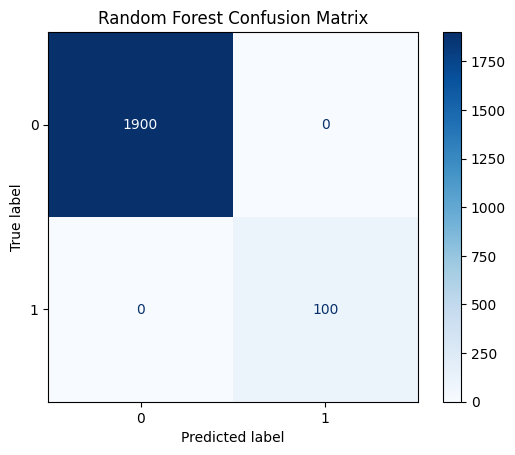

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
16,current_assets_total_liabilities,0.090000
17,short_term_liabilities_total_assets,0.090000
3,current_assets_short_term_liabilities,0.085435
22,profit_on_sales,0.080000
18,equity_fixed_assets,0.075000
1,total_liabilities_total_assets,0.070000
23,ebit_sales,0.070000
19,constant_capital_fixed_assets,0.065000
9,gross_profit_short_term_liabilities,0.055418
20,working_capital,0.055000


In [41]:
correlation = df.corr()["class"].sort_values(ascending=False)

print(correlation.head(10))

class                                        1.000000
total_liabilities_total_assets               0.723821
short_term_liabilities_total_assets          0.701552
operating_expenses_short_term_liabilities    0.195211
operating_expenses_total_liabilities         0.187158
rotation_receivables_inventories            -0.149782
total_assets                                -0.191064
total_costs                                 -0.222784
revenue                                     -0.274141
sales_n_1                                   -0.287453
Name: class, dtype: float64


In [42]:
print(correlation.tail(10))

working_capital_total_assets                  -0.578886
gross_profit_sales                            -0.598627
ebit_total_assets                             -0.624324
ebit_sales                                    -0.644995
equity_total_assets                           -0.660316
profit_on_operating_activities_total_assets   -0.661019
gross_profit_total_assets                     -0.664005
profit_on_sales                               -0.705752
net_profit_total_assets                       -0.719151
net_profit_sales                              -0.785355
Name: class, dtype: float64


<Figure size 600x600 with 0 Axes>

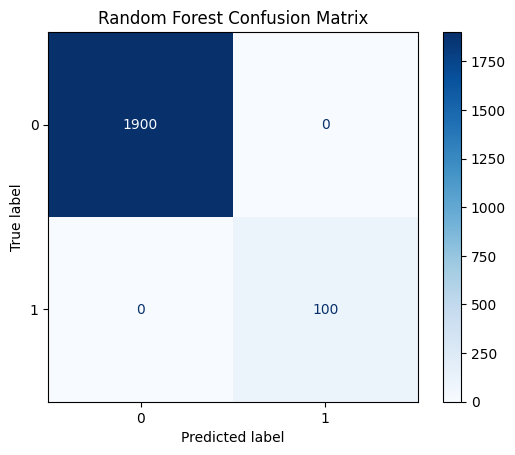

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 1000x600 with 0 Axes>

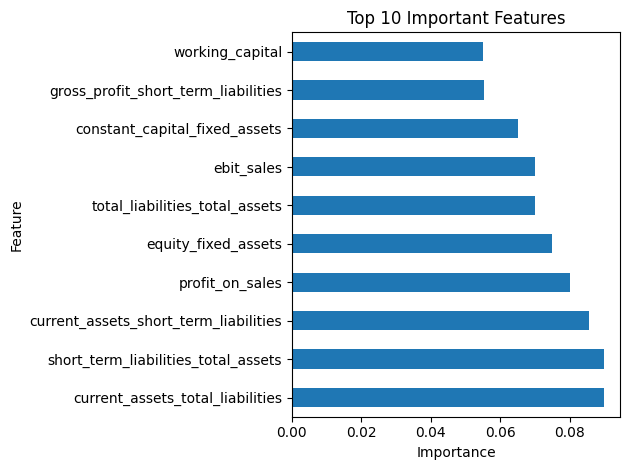

In [44]:
plt.figure(figsize=(10,6))

feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

In [45]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(rf, "models/bankruptcy_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']